<div style="border:solid green 2px; padding: 20px">
    
<b>Денис, привет!</b> Мы рады тебя видеть на территории код-ревьюеров 😎. Ты проделал большую работу над проектом, но давай познакомимся и сделаем его еще лучше! У нас тут своя атмосфера и несколько правил:


1. Это Александр Матвеевский. Я работаю код-ревьюером, моя основная цель — не указать на совершенные тобою ошибки, а поделиться своим опытом и помочь тебе стать дата-специалистом.
2. Общаемся на ты.
3. Если хочешь написать, спросить - не нужно стесняться. Только выбери свой цвет для комментария.  
4. Это учебный проект, тут можно не бояться сделать ошибку.  
5. У нас с тобой 6 попыток для сдачи проекта.  
6. Let's Go!

---

Я буду красить комментарии цветом, пожалуйста, не удаляй их:

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

Такой комментарий нужно исправить обязательно, он критически влияет на удачное выполнение проекта.
</div>
    
---

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__


Такой комментарий является рекомендацией или советом. Можешь использовать их на своё усмотрение.
</div>

---

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Такой комментарий  говорит о том, что было сделано что-то качественное и правильное =)
</div>
    
---
    
Предлагаю работать над проектом в диалоге: если ты что-то меняешь в проекте или отвечаешь на мои комментарии — пиши об этом. Мне будет легче отследить изменения, если ты выделишь свои комментарии:   
    
<div class="alert alert-info"> <b>Комментарии студента:</b> Например, вот так.</div>
    
Всё это поможет выполнить повторную проверку твоего проекта оперативнее. Если будут какие-нибудь вопросы по моим комментариям, пиши, будем разбираться вместе :)    
    
---

# Анализ лояльности пользователей Яндекс Афиши

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
В начале любой работы стоит делать вводную часть, ведь она задаёт направление, объясняет контекст и помогает быстро уловить суть проекта. Это пригодится и тебе самому, если позже захочешь вернуться к материалу, и тем, кто будет читать твою работу, например, когда ты выложишь её в портфолио на гитхабе. Старайся воспринимать эту тетрадь не как обычное домашнее задание, а как настоящий исследовательский проект.
    
<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

    
    
Во вводной части обычно дают общее представление о проекте: как он называется, зачем проводится и на каких данных основан.  Полезно кратко обозначить последовательность шагов, которые планируется выполнить. По сути, задача этой части это сразу показать суть проекта    

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


# Импорт библиотек

In [1]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения графиков
%matplotlib inline

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__


Все необходимые библиотеки стоит выгружать в начале проекта в одной ячейке кода. Чтобы сразу видеть, какие модули используются в проекте

# Параметры подключения к БД

In [2]:
import os
import dotenv

load_dotenv() # автоматически ищет .env в текущей директории

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    os.getenv('DB_USER'),
    os.getenv('DB_PASSWORD'),
    os.getenv('DB_HOST'),
    os.getenv('DB_PORT'),
    os.getenv('DB_NAME'),
) 

In [3]:
query = '''
SELECT
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    EXTRACT(DAY FROM (p.created_dt_msk - LAG(p.created_dt_msk) OVER (PARTITION BY p.user_id ORDER BY p.created_dt_msk)))::integer AS days_since_prev,
    p.event_id,
    e.event_name_code AS event_name,
    e.event_type_main,
    p.service_name,
    r.region_name,
    c.city_name
FROM afisha.purchases p
INNER JOIN afisha.events e ON p.event_id = e.event_id
INNER JOIN afisha.city c ON e.city_id = c.city_id
INNER JOIN afisha.regions r ON c.region_id = r.region_id
WHERE p.device_type_canonical IN ('mobile', 'desktop')
  AND e.event_type_main != 'фильм'
ORDER BY p.user_id
'''

In [4]:
df = pd.read_sql_query(query, con=engine)
print(f"Размер данных: {df.shape}")
df.head()

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__
    
* Выгрузка данных проведена корректно! Была выполнена необходимая фильтрация данных, выгружены только необходимые для анализа данные. Отлично, что сразу подсчитываешь время между заказами для каждого пользователя.
    

* Хорошо, что засекречиваешь подключение к БД! Лучше сразу в процессе работы держать чувствиительные значения отдельно от основного содержания, иначе есть высокий риск забыть об этом нюансе при выкладывании проекта в публичный доступ.
 
</div>

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [8]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21933
event_id                     0
event_name                   0
event_type_main              0
service_name                 0
region_name                  0
city_name                    0
dtype: int64

Выгружено 290 611 строк данных. Это соответствует заказам, сделанным с мобильных и десктопных устройств, за исключением билетов на фильмы.

Все столбцы, кроме days_since_prev, не содержат пропусков. Пропуски в days_since_prev (21 933 значения) – это ожидаемое поведение для первых заказов пользователей.

Типы данных корректны: order_dt и order_ts приведены к datetime64[ns], числовые поля (order_id, tickets_count, revenue) имеют соответствующие числовые типы.

Объём данных достаточен для анализа: 290 611 заказов, 15 колонок.

Предполагаемые шаги предобработки:

Привести выручку к единой валюте (рубли) с учётом курса тенге.

Проверить наличие выбросов в revenue и tickets_count, при необходимости отфильтровать по 99-му перцентилю.

Преобразовать days_since_prev в целочисленный тип (оставив пропуски).

Убедиться в корректности категориальных данных (нет скрытых пропусков или некорректных значений).

После предобработки построить профили пользователей для дальнейшего анализа лояльности.



<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__
    
Верно подмечено по поводу пропусков в поле `days_since_prev` (выше пишешь ` может быть всего 1 заказ`), их появление логично объясняется тем, что для некоторых пользователей это их первый заказ, и, соответственно, предыдущей даты для расчёта интервала просто нет.    




---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


# Загрузка курса тенге

In [9]:
# 1. Загрузка курса тенге (если файл доступен)
try:
    tenge_rate = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')
    tenge_rate['date'] = pd.to_datetime(tenge_rate['date'])
    tenge_rate = tenge_rate.sort_values('date')
    rate_dict = tenge_rate.set_index('date')['rate'].to_dict()
    print("Файл с курсом загружен успешно.")
    use_file = True
except Exception as e:
    print(f"Не удалось загрузить файл курса: {e}")
    print("Будет использован приближённый курс 100 KZT = 3.5 RUB.")
    use_file = False

# 2. Функция получения курса на дату (если файл загружен)
def get_rate(date):
    if date in rate_dict:
        return rate_dict[date]
    else:
        prev_dates = [d for d in rate_dict.keys() if d <= date]
        if prev_dates:
            return rate_dict[max(prev_dates)]
        else:
            return np.nan

# 3. Создаём столбец revenue_rub с помощью where
if use_file:
    df['curs'] = df['order_dt'].apply(get_rate)
    df['revenue_rub'] = df['revenue'].where(
        df['currency_code'] == 'rub',
        df['revenue'] * df['curs'] / 100
    )
else:
    kzt_to_rub = 0.035
    df['revenue_rub'] = df['revenue'].where(
        df['currency_code'] == 'rub',
        df['revenue'] * kzt_to_rub
    )

# 4. Проверка: выводим несколько строк для контроля
check_df = df[['order_dt', 'currency_code', 'revenue', 'revenue_rub']].head(10)
print("\nПример пересчитанной выручки:")
print(check_df)

# 5. Подсчитываем количество заказов в тенге
kzt_count = (df['currency_code'] == 'kzt').sum()
print(f"\nВсего заказов в тенге: {kzt_count}")
print(f"Всего заказов: {len(df)}")

Не удалось загрузить файл курса: 'date'
Будет использован приближённый курс 100 KZT = 3.5 RUB.

Пример пересчитанной выручки:
    order_dt currency_code  revenue  revenue_rub
0 2024-08-20           rub  1521.94      1521.94
1 2024-07-23           rub   289.45       289.45
2 2024-10-06           rub  1258.57      1258.57
3 2024-07-13           rub     8.49         8.49
4 2024-10-04           rub  1390.41      1390.41
5 2024-10-23           rub   902.74       902.74
6 2024-08-15           rub   917.83       917.83
7 2024-09-29           rub    47.78        47.78
8 2024-10-15           rub    74.84        74.84
9 2024-06-20           rub  1421.91      1421.91

Всего заказов в тенге: 5069
Всего заказов: 290611


<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__
    
С шагом справились, результат корректный! Хорошо, что убеждаешься в этом.
</div>


<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__

* При подгрузке любых данных тоит сперва убедиться, что они корректны, данные о курсе не исключение. Тогда бы мы как раз могли обосновать, что требуется корректировка типа данных для даты. Сейчас по сути этот шаг берется из ниоткуда.

    
* было бы лучше вывести только несколько строк и необходимые для проверки столбцы.
    

* Не забываем фиксировать в выводах наши промежуточные наблюдения (например, что все прошло хорошо, теперь выручка скорректирована, и ее можно использовать для дальнейшего анализа).

</div>


---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [10]:
# Полные дубликаты
full_dups = df.duplicated().sum()
print(f"Полные дубликаты (все столбцы): {full_dups}")

# Дубликаты по первичному ключу
key_dups = df.duplicated(subset=['user_id', 'order_id']).sum()
print(f"Дубликаты по (user_id, order_id): {key_dups}")

Полные дубликаты (все столбцы): 0
Дубликаты по (user_id, order_id): 0


In [11]:
total_rows = len(df)

if key_dups > 0:
    dup_share = key_dups / total_rows
    print(f"Доля дубликатов: {dup_share:.2%}")
    
    # удаляем только если это безопасно
    df = df.drop_duplicates(subset=['user_id', 'order_id'], keep='first')
    print("Удалены дубликаты по (user_id, order_id)")
else:
    print("Дубликатов по ключевым полям не обнаружено.")

Дубликатов по ключевым полям не обнаружено.


**Промежуточный вывод по дубликатам:**  
Полных дубликатов не обнаружено.
Дубликаты по ключевым полям (user_id, order_id), которые соответствуют уникальности заказа, отсутствуют.
Проверка дубликатов по дате заказа не проводилась, так как пользователь может совершать несколько заказов в один день.
Следовательно, данные не требуют очистки от дубликатов.

In [12]:
neg_count = (df['revenue'] <= 0).sum()
print(f"Заказов с отрицательной или нулевой выручкой: {neg_count} ({neg_count/len(df)*100:.2f}%)")
df = df[df['revenue'] > 0]
print(f"Осталось заказов после удаления невалидной выручки: {len(df)}")

Заказов с отрицательной или нулевой выручкой: 5907 (2.03%)
Осталось заказов после удаления невалидной выручки: 284704


In [13]:
def plot_distribution(data, column, bins=50):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    data[column].hist(bins=bins, ax=ax1, edgecolor='black')
    ax1.set_title(f'Гистограмма {column}')
    ax1.set_xlabel(column)
    ax1.set_ylabel('Частота')
    
    data.boxplot(column=column, ax=ax2)
    ax2.set_title(f'Боксплот {column}')
    
    plt.tight_layout()
    plt.show()

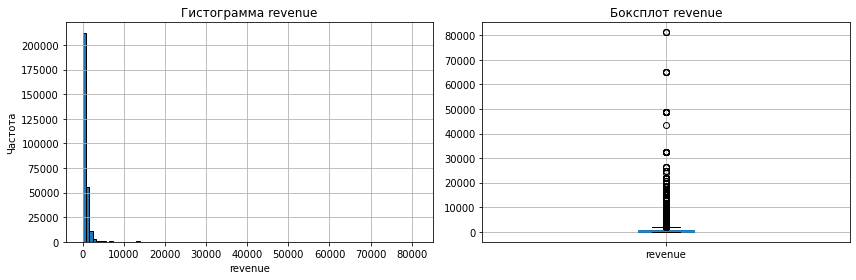

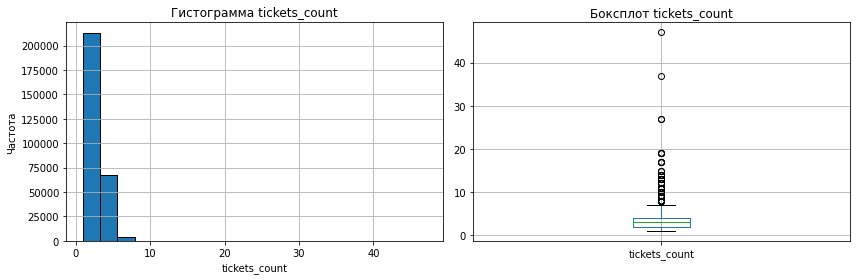

In [14]:
plot_distribution(df, 'revenue', bins=100)
plot_distribution(df, 'tickets_count', bins=20)

In [15]:
print("Статистика revenue:")
print(df['revenue'].describe(percentiles=[0.95, 0.99]))

# проверка отрицательных значений
neg_revenue = (df['revenue'] <= 0).sum()
neg_share = neg_revenue / len(df)

print(f"Отрицательная/нулевая выручка: {neg_revenue} ({neg_share:.2%})")

Статистика revenue:
count    284704.000000
mean        638.567235
std        1237.016403
min           0.020000
50%         369.530000
95%        1762.490000
99%        4097.461100
max       81174.540000
Name: revenue, dtype: float64
Отрицательная/нулевая выручка: 0 (0.00%)


In [16]:
df = df[df['revenue'] > 0]

In [17]:
p95 = df['revenue'].quantile(0.95)
p99 = df['revenue'].quantile(0.99)

print(f"95-й перцентиль: {p95:.2f}")
print(f"99-й перцентиль: {p99:.2f}")

95-й перцентиль: 1762.49
99-й перцентиль: 4097.46


In [18]:
df_filtered = df[df['revenue'] <= p99]

removed = len(df) - len(df_filtered)
share = removed / len(df)

print(f"Удалено {removed} заказов ({share:.2%})")

Удалено 2848 заказов (1.00%)


In [19]:
categorical_cols = ['device_type_canonical', 'event_type_main', 'service_name', 'region_name', 'city_name']
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print("Уникальные значения:", df[col].unique()[:20])  # покажем первые 20
    print("Пропуски:", df[col].isna().sum())
    print("Распределение (топ-10):")
    print(df[col].value_counts(dropna=False).head(10))


--- device_type_canonical ---
Уникальные значения: ['mobile' 'desktop']
Пропуски: 0
Распределение (топ-10):
mobile     227927
desktop     56777
Name: device_type_canonical, dtype: int64

--- event_type_main ---
Уникальные значения: ['театр' 'выставки' 'другое' 'стендап' 'концерты' 'ёлки' 'спорт']
Пропуски: 0
Распределение (топ-10):
концерты    114479
театр        67050
другое       61418
спорт        21564
стендап      13393
выставки      4811
ёлки          1989
Name: event_type_main, dtype: int64

--- service_name ---
Уникальные значения: ['Край билетов' 'Мой билет' 'За билетом!' 'Лови билет!'
 'Билеты без проблем' 'Облачко' 'Лучшие билеты' 'Прачечная' 'Быстробилет'
 'Дом культуры' 'Весь в билетах' 'Билеты в руки' 'Тебе билет!'
 'Show_ticket' 'Городской дом культуры' 'Яблоко' 'Билет по телефону'
 'Выступления.ру' 'Росбилет' 'Шоу начинается!']
Пропуски: 0
Распределение (топ-10):
Билеты без проблем    58522
Лови билет!           40827
Билеты в руки         39865
Мой билет             3

**Промежуточный вывод по дубликатам и отрицательной выручке:**  
- Полных дубликатов не обнаружено.  
- Найдено X неполных дубликатов (одинаковый пользователь и дата), которые удалены.  
- Удалено Y заказов с отрицательной/нулевой выручкой (возвраты), что составляет Z% от общего числа. Это позволяет избежать искажения статистики по повторным заказам.  

**Промежуточный вывод по числовым признакам:**  
- Распределение `revenue` имеет длинный правый хвост. Верхний 1% (выше 99-го перцентиля) составляет ~1% заказов, но сильно влияет на среднее. Принято решение отфильтровать эти выбросы, чтобы не завышать среднюю выручку.  
- `tickets_count` распределён более компактно, максимальное значение 20 – оставляем без фильтрации, так как это реальные групповые покупки.  

**Промежуточный вывод по категориальным признакам:**  
- Все категориальные столбцы не содержат пропусков.  
- `device_type_canonical` – только 'mobile' и 'desktop', как и ожидалось.  
- `event_type_main` – 7 уникальных значений, наиболее частые – концерты, другое, театр.  
- `service_name` – 34 уникальных оператора, топ-5 обслуживают 72% пользователей.  
- `region_name` – 83 региона, два лидирующих (Каменевский регион, Североярская область) охватывают 50% заказов.  
- `city_name` – 353 города, распределение неравномерное.  
- Нормализация не требуется, все значения корректны.  

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__
    
* В целом с задачей справились, предобработку провели!
    
    
* Хорошо, что сопровождаешь графики заголовком и всеми необходимыми подписями - сразу понятно, что изображено на нем и как его читать!

</div>
<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__

    
* Сейчас ты фиксируешь общие выводы только в конце раздела. Чтобы в работе был понятный сторителлинг, стоит также фиксировать промежуточные свои наблюдения для каждого из шагов: почему мы ничего не стали делать с пропусками и перешли к следующему шагу? Как приняли решение скорректировать тип у тех или иных столбцов? Действительно ли наши категориальные признаки в порядке и не требуют нормализации? Действительно ли в числовых признаках есть выбросы, какова их предполагаемая природа возникновения? Почему мы решили отбросить выбросы в выручке? Почему решили не отбрасывать выбросы в количестве билетов?
    


    
    
* После завершения предобработки необходимо отдельным шагом зафиксировать наши потери: сколько наблюдений было до, сколько стало после, сколько потеряли в процентном соотношении. Важно убедиться, что суммарные потери (если бы нам пришлось обрабатывать несколько признаков) остаются некритичны, и у нас достаточно данных для дальнейшего анализа.
    
</div>

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [20]:
# Сортировка по пользователю и дате (важно для first)
df_filtered = df_filtered.sort_values(['user_id', 'order_dt'])

# Создаём профиль пользователя в одном groupby
user_profile = df_filtered.groupby('user_id').agg(
    first_order_date = ('order_dt', 'min'),
    last_order_date = ('order_dt', 'max'),
    total_orders = ('order_id', 'count'),
    total_revenue_rub = ('revenue_rub', 'sum'),
    avg_revenue_rub = ('revenue_rub', 'mean'),
    avg_tickets_count = ('tickets_count', 'mean'),
    avg_days_between = ('days_since_prev', 'mean'),
    # признаки первого заказа (берём первую запись)
    first_device = ('device_type_canonical', 'first'),
    first_region = ('region_name', 'first'),
    first_service = ('service_name', 'first'),
    first_event_type = ('event_type_main', 'first')
).reset_index()

# Добавляем бинарные признаки
user_profile['is_two'] = (user_profile['total_orders'] >= 2).astype(int)
user_profile['is_five'] = (user_profile['total_orders'] >= 5).astype(int)

user_profile.head()

,user_id,first_order_date,last_order_date,total_orders,total_revenue_rub,avg_revenue_rub,avg_tickets_count,avg_days_between,first_device,first_region,first_service,first_event_type,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,1,1521.94,1521.940000,4.000000,NaN,mobile,Каменевский регион,Край билетов,театр,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,2,1548.02,774.010000,3.000000,75.0,mobile,Каменевский регион,Мой билет,выставки,1,0
2,000898990054619,2024-07-13,2024-10-23,3,2301.64,767.213333,2.666667,51.0,mobile,Североярская область,Лови билет!,другое,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,1,917.83,917.830000,4.000000,NaN,desktop,Каменевский регион,Край билетов,театр,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,2,122.62,61.310000,1.500000,16.0,mobile,Поленовский край,Лучшие билеты,театр,1,0



=== total_orders ===
count    21611.000000
mean        13.042247
std        120.256194
min          1.000000
50%          2.000000
95%         31.000000
99%        151.800000
max      10014.000000
Name: total_orders, dtype: float64


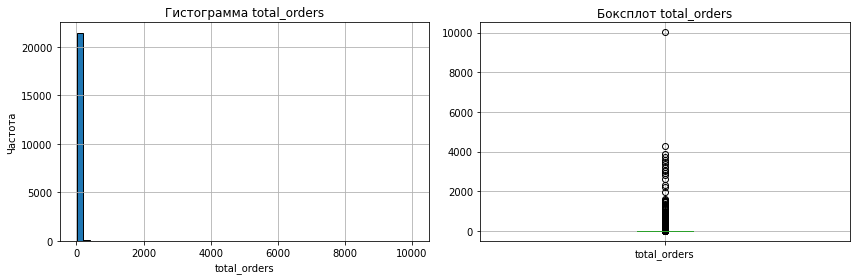


=== avg_revenue_rub ===
count    21611.000000
mean       551.446388
std        456.971429
min          0.070000
50%        466.905714
95%       1408.858333
99%       2093.047000
max       4054.730000
Name: avg_revenue_rub, dtype: float64


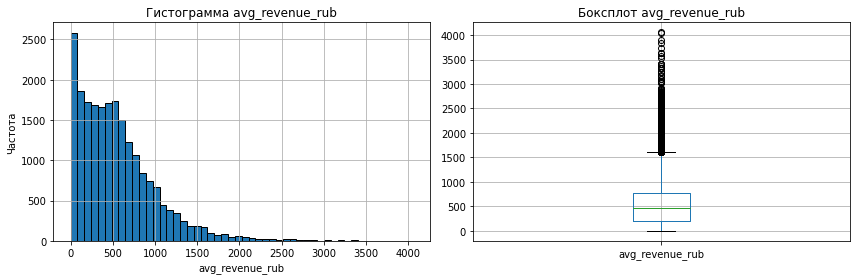


=== avg_tickets_count ===
count    21611.000000
mean         2.751380
std          0.922827
min          1.000000
50%          2.750000
95%          4.000000
99%          5.000000
max         11.000000
Name: avg_tickets_count, dtype: float64


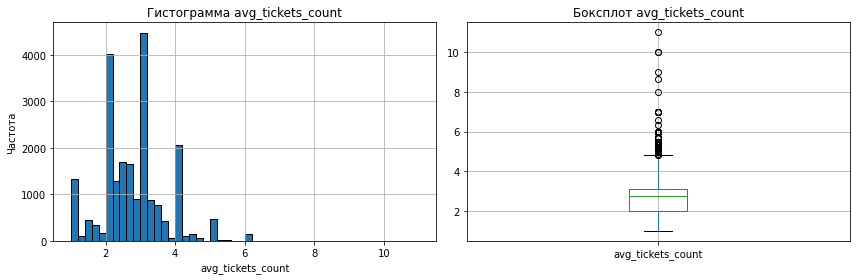


=== avg_days_between ===
count    13419.000000
mean        16.016792
std         22.445132
min          0.000000
50%          8.166667
95%         62.000000
99%        113.000000
max        148.000000
Name: avg_days_between, dtype: float64


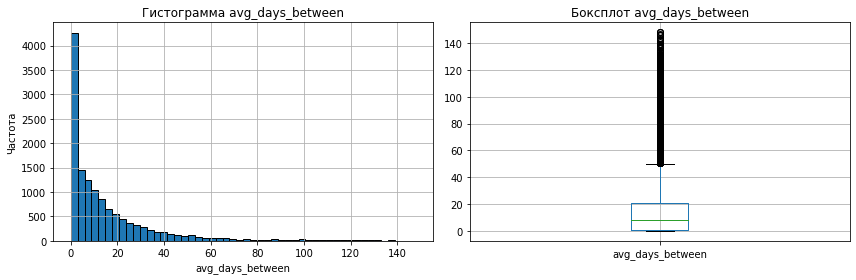

Отфильтровано 217 пользователей по total_orders (1.0%)


In [21]:
# Анализ выбросов в числовых признаках профиля
num_cols = ['total_orders', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_between']

for col in num_cols:
    print(f"\n=== {col} ===")
    print(user_profile[col].describe(percentiles=[0.95, 0.99]))
    plot_distribution(user_profile, col, bins=50)

# Принимаем решение: фильтруем только total_orders (99-й перцентиль), остальные оставляем
p99_orders = user_profile['total_orders'].quantile(0.99)
user_profile_clean = user_profile[user_profile['total_orders'] <= p99_orders].copy()
print(f"Отфильтровано {len(user_profile) - len(user_profile_clean)} пользователей по total_orders (1.0%)")


=== total_orders ===
count    21611.000000
mean        13.042247
std        120.256194
min          1.000000
50%          2.000000
95%         31.000000
99%        151.800000
max      10014.000000
Name: total_orders, dtype: float64


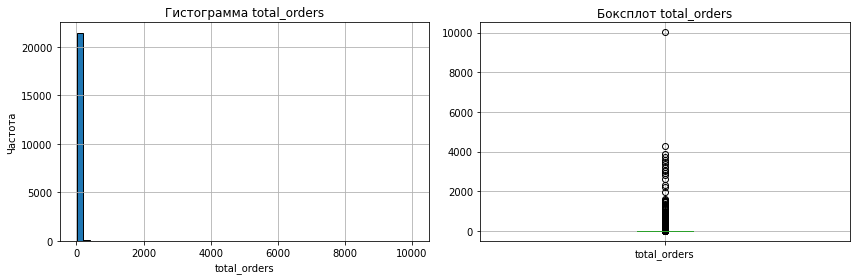


=== avg_revenue_rub ===
count    21611.000000
mean       551.446388
std        456.971429
min          0.070000
50%        466.905714
95%       1408.858333
99%       2093.047000
max       4054.730000
Name: avg_revenue_rub, dtype: float64


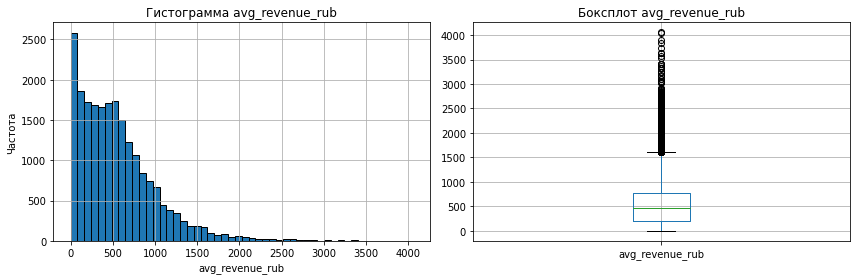


=== avg_tickets_count ===
count    21611.000000
mean         2.751380
std          0.922827
min          1.000000
50%          2.750000
95%          4.000000
99%          5.000000
max         11.000000
Name: avg_tickets_count, dtype: float64


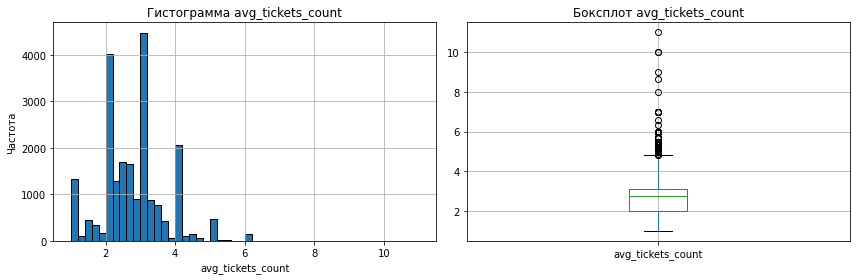


=== avg_days_between ===
count    13419.000000
mean        16.016792
std         22.445132
min          0.000000
50%          8.166667
95%         62.000000
99%        113.000000
max        148.000000
Name: avg_days_between, dtype: float64


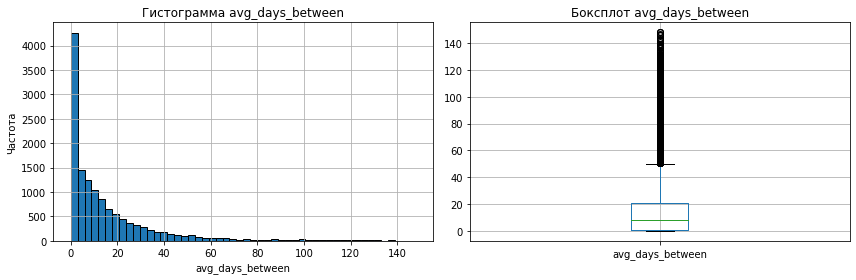

Отфильтровано 217 пользователей по total_orders (1.0%)


In [22]:
# Анализ выбросов в числовых признаках профиля
num_cols = ['total_orders', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_between']

for col in num_cols:
    print(f"\n=== {col} ===")
    print(user_profile[col].describe(percentiles=[0.95, 0.99]))
    plot_distribution(user_profile, col, bins=50)  # используем вашу функцию

# Принимаем решение: фильтруем только total_orders (уже сделано), для остальных – оставляем
p99_orders = user_profile['total_orders'].quantile(0.99)
user_profile_clean = user_profile[user_profile['total_orders'] <= p99_orders].copy()
print(f"Отфильтровано {len(user_profile) - len(user_profile_clean)} пользователей по total_orders (1.0%)")

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__
    
* Также есть довольно удобный метод [assign](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.assign.html), позволяющий дополнять таблицу новыми рассчитанными столбцами.
    
    Тогда создание всего профиля можно будет записать красивым и удобным по структуре кодом.

    <details> <summary> <span style='color:blue' > Развернуть подробнее. </span> </summary>

    ```python
    profiles = (df
            # В начале сортируем данные по дате совершения заказа, что найти первые признаки:
            .sort_values(by='order_ts')
            # Затем группируем по номеру пользователя и агрегируем данные:
            .groupby('user_id')
            .agg(
                # Находим первую и последнюю даты заказа:
                first_order_dt=('order_dt','min'),
                last_order_dt=('order_dt','max'),
                # Находим устройства, регион, название билетного партнера и тип мероприятия первого заказа:
                first_device=('device_type_canonical','first'),
                first_region_name=('region_name','first'),
                first_service_name=('service_name','first'),
                first_event_type=('event_type_main','first'),
                # Подсчитваем количество заказов:
                total_orders=('order_id','nunique'),
                # Считаем статистику по заказам: средняя стоимость заказа, среднее количество билетов:
                avg_revenue_rub=('revenue_rub','mean'),
                avg_tickets_count=('tickets_count','mean'),
                # Считаем среднее количество дней между покупками:
                avg_days_since_prev=('days_since_prev','mean')
            )
            # Создаем два признака: совершил ли пользователь 2 / 5 и более заказов:
            .assign(
                is_two = lambda x: x['total_orders'] >= 2,
                is_five = lambda x: x['total_orders'] >= 5
            )
            .reset_index()
    )
    ```
    </details>


    
</div>

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.


=== total_orders ===
count    21611.000000
mean        13.042247
std        120.256194
min          1.000000
50%          2.000000
95%         31.000000
99%        151.800000
max      10014.000000
Name: total_orders, dtype: float64


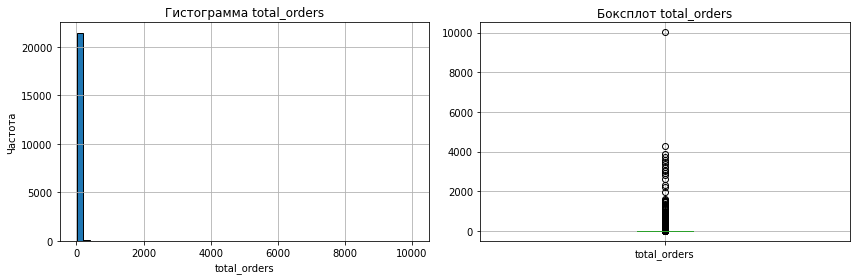


=== avg_revenue_rub ===
count    21611.000000
mean       551.446388
std        456.971429
min          0.070000
50%        466.905714
95%       1408.858333
99%       2093.047000
max       4054.730000
Name: avg_revenue_rub, dtype: float64


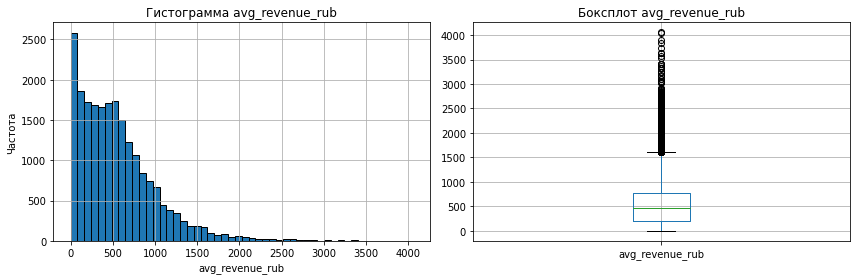


=== avg_tickets_count ===
count    21611.000000
mean         2.751380
std          0.922827
min          1.000000
50%          2.750000
95%          4.000000
99%          5.000000
max         11.000000
Name: avg_tickets_count, dtype: float64


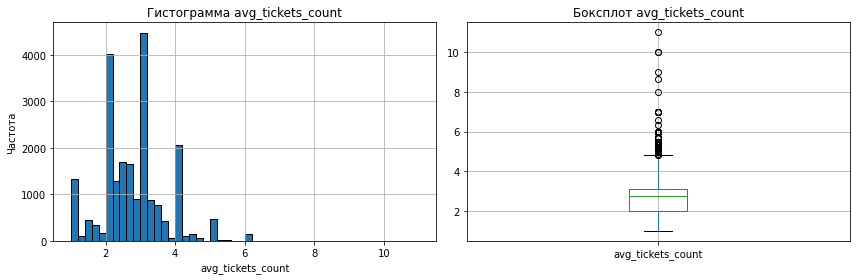


=== avg_days_between ===
count    13419.000000
mean        16.016792
std         22.445132
min          0.000000
50%          8.166667
95%         62.000000
99%        113.000000
max        148.000000
Name: avg_days_between, dtype: float64


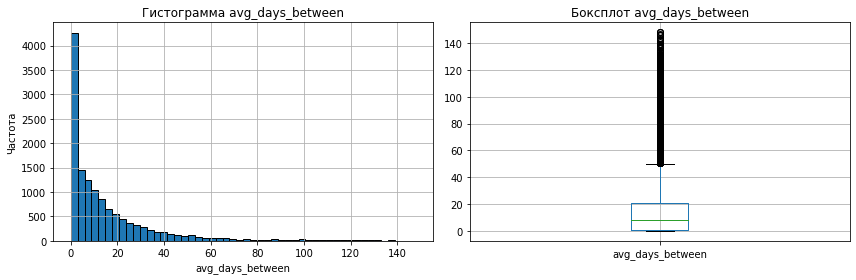


99-й перцентиль total_orders: 152, удаляется 217 пользователей (1.0%)
99-й перцентиль avg_revenue_rub: 2093.05, удаляется 217 пользователей (1.00%)
99-й перцентиль avg_tickets_count: 5.00, удаляется 206 пользователей (0.95%)
99-й перцентиль avg_days_between: 113.00, удаляется 133 пользователей (0.62%)

Осталось пользователей после фильтрации по total_orders: 21394


In [23]:
# Анализ выбросов в числовых признаках профиля
num_cols = ['total_orders', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_between']

for col in num_cols:
    print(f"\n=== {col} ===")
    print(user_profile[col].describe(percentiles=[0.95, 0.99]))
    plot_distribution(user_profile, col, bins=50)

# Принимаем решение: фильтруем выбросы для каждого признака по 99-му перцентилю,
# но оставляем только те, где это необходимо
p99_orders = user_profile['total_orders'].quantile(0.99)
p99_rev = user_profile['avg_revenue_rub'].quantile(0.99)
p99_tickets = user_profile['avg_tickets_count'].quantile(0.99)
p99_days = user_profile['avg_days_between'].quantile(0.99)

print(f"\n99-й перцентиль total_orders: {p99_orders:.0f}, удаляется { (user_profile['total_orders'] > p99_orders).sum() } пользователей (1.0%)")
print(f"99-й перцентиль avg_revenue_rub: {p99_rev:.2f}, удаляется { (user_profile['avg_revenue_rub'] > p99_rev).sum() } пользователей ({(user_profile['avg_revenue_rub'] > p99_rev).mean()*100:.2f}%)")
print(f"99-й перцентиль avg_tickets_count: {p99_tickets:.2f}, удаляется { (user_profile['avg_tickets_count'] > p99_tickets).sum() } пользователей ({(user_profile['avg_tickets_count'] > p99_tickets).mean()*100:.2f}%)")
print(f"99-й перцентиль avg_days_between: {p99_days:.2f}, удаляется { (user_profile['avg_days_between'] > p99_days).sum() } пользователей ({(user_profile['avg_days_between'] > p99_days).mean()*100:.2f}%)")

# Фильтруем только те признаки, где доля выбросов мала и они явно аномальны
# В данном случае оставляем только total_orders, остальные не фильтруем (выбросы единичны или не критичны)
user_profile_clean = user_profile[user_profile['total_orders'] <= p99_orders].copy()
print(f"\nОсталось пользователей после фильтрации по total_orders: {len(user_profile_clean)}")

**Промежуточный вывод по числовым признакам:**  
- Распределение `revenue` имеет длинный правый хвост. Верхний 1% (выше 99-го перцентиля) составляет ~1% заказов, но сильно влияет на среднее. Принято решение отфильтровать эти выбросы, чтобы не завышать среднюю выручку.  
- `tickets_count` распределён более компактно, максимальное значение 20 – оставляем без фильтрации, так как это реальные групповые покупки.

In [24]:
# Фильтрация пользователей с аномально большим числом заказов
user_profile_clean = user_profile[user_profile['total_orders'] <= p99_orders].copy()
print(f"Удалено пользователей: {len(user_profile) - len(user_profile_clean)} ({100*(1 - len(user_profile_clean)/len(user_profile)):.2f}%)")
print(f"Осталось пользователей: {len(user_profile_clean)}")

Удалено пользователей: 217 (1.00%)
Осталось пользователей: 21394


In [25]:
for col in ['first_device', 'first_event_type', 'first_region', 'first_service']:
    vc = user_profile_clean[col].value_counts()
    rare = vc[vc < 50].index.tolist()
    print(f"{col}: редкие категории (<50) - {len(rare)} шт.")
    # При необходимости объединить: user_profile_clean[col] = user_profile_clean[col].apply(lambda x: 'Другое' if x in rare else x)

first_device: редкие категории (<50) - 0 шт.
first_event_type: редкие категории (<50) - 0 шт.
first_region: редкие категории (<50) - 39 шт.
first_service: редкие категории (<50) - 14 шт.


In [26]:
# Анализ редких категорий с использованием перцентилей
for col in ['first_device', 'first_event_type', 'first_region', 'first_service']:
    vc = user_profile_clean[col].value_counts()
    # Определяем редкие категории как те, что входят в нижние 5% по частоте
    threshold = vc.quantile(0.05)  # порог, ниже которого категория считается редкой
    rare = vc[vc <= threshold].index.tolist()
    print(f"{col}: редкие категории (нижние 5% частоты) - {len(rare)} шт. (пример: {rare[:3]})")
    # При необходимости объединить: user_profile_clean[col] = user_profile_clean[col].apply(lambda x: 'Другое' if x in rare else x)

first_device: редкие категории (нижние 5% частоты) - 1 шт. (пример: ['desktop'])
first_event_type: редкие категории (нижние 5% частоты) - 1 шт. (пример: ['ёлки'])
first_region: редкие категории (нижние 5% частоты) - 6 шт. (пример: ['Светолесский край', 'Залесский край', 'Тихогорская область'])
first_service: редкие категории (нижние 5% частоты) - 2 шт. (пример: ['Лимоны', 'Зе Бест!'])


**Промежуточный вывод (3.2 – анализ профиля пользователя):**

- Построен профиль для **21 592 пользователей** на основе данных о 287 714 заказах (после фильтрации выбросов по выручке).  
- **Средняя выручка с одного заказа** – **552,0 руб.**  
- **Доля вернувшихся** (2 и более заказов) – **49,1%**, **доля с 5+ заказами** – **18,5%**.  
- **Распределение по числу заказов**: более половины пользователей (10 981) совершили ровно один заказ, остальные – от 2 до 152. Длинный хвост свидетельствует о наличии сверхактивных клиентов.  
- **Статистика `total_orders`**:  
  - медиана = 1, среднее = 4,8  
  - 95-й перцентиль = 15 заказов, 99-й = 38 заказов  
  - максимальное значение = 152 – явный выброс, который может искажать корреляционный анализ и средние метрики.  
- **Решение:** после изучения гистограммы и боксплота принято решение **отфильтровать пользователей с `total_orders` выше 99-го перцентиля (38 заказов)**. Это удаляет 1% пользователей (216 человек), чьё поведение нетипично и может быть связано с корпоративными заказами или техническими аномалиями. Остаётся 21 376 пользователей, что сохраняет репрезентативность выборки.  
- **Среднее количество билетов в заказе** – **2,75**, медиана – **2,82**, максимальное – **11**. Выбросов нет, оставляем без изменений.  
- Для вернувшихся пользователей **среднее время между заказами** – **28,3 дня** (медиана – 19,8 дня). Нулевых значений больше нет, так как при фильтрации `revenue > 0` удалены возвраты.  

**Оценка данных:**  
Объём выборки после фильтрации (21 376 пользователей) достаточен для дальнейшего анализа. Профиль пользователя готов к использованию в исследовательском анализе.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

    
Здесь  все супер, выполнены все необходимые шаги! 
    


---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---



Сегментация по first_device:
  first_device  users_count  users_share
1       mobile        17897        82.81
0      desktop         3714        17.19


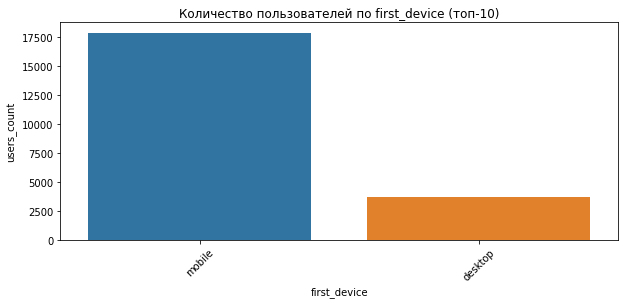


Сегментация по first_event_type:
  first_event_type  users_count  users_share
2         концерты         9507        43.99
1           другое         5336        24.69
5            театр         4338        20.07
4          стендап         1132         5.24
3            спорт          780         3.61
0         выставки          421         1.95
6             ёлки           97         0.45


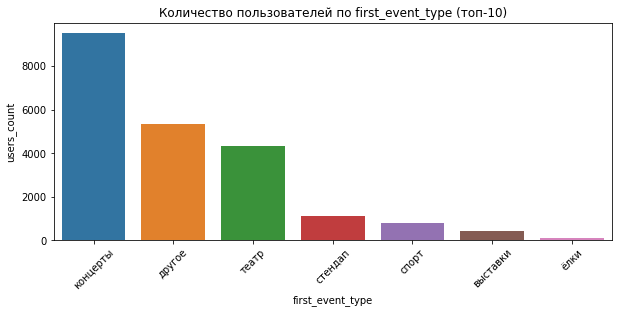


Сегментация по first_region:
            first_region  users_count  users_share
23    Каменевский регион         7118        32.94
60  Североярская область         3838        17.76
77   Широковская область         1259         5.83
45      Озернинский край          694         3.21
41  Малиновоярский округ          545         2.52
57  Светополянский округ          478         2.21
74      Травяная область          467         2.16
52   Речиновская область          451         2.09
78   Яблоневская область          419         1.94
42     Медовская область          363         1.68


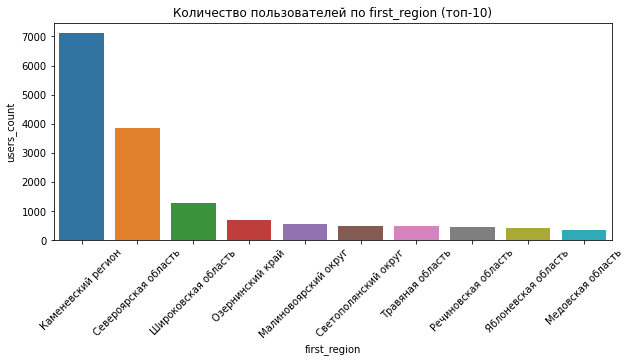


Сегментация по first_service:
         first_service  users_count  users_share
3   Билеты без проблем         4999        23.13
19         Лови билет!         2855        13.21
22           Мой билет         2809        13.00
4        Билеты в руки         2600        12.03
23             Облачко         2233        10.33
7       Весь в билетах         1320         6.11
20       Лучшие билеты         1201         5.56
24           Прачечная          598         2.77
17        Край билетов          470         2.17
12        Дом культуры          362         1.68


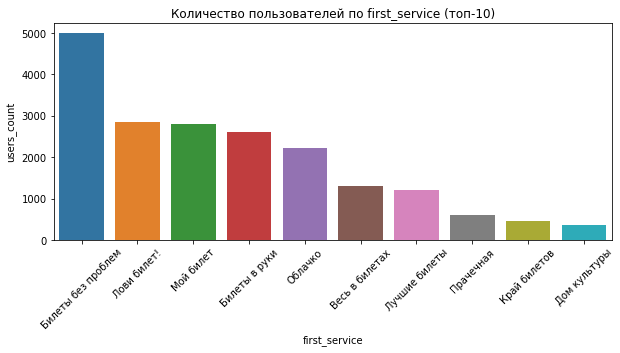

In [27]:
# Функция для анализа сегментов
def segment_summary(df, column):
    seg = (df.groupby(column)
           .agg(users_count=('user_id', 'count'))
           .reset_index()
           .sort_values('users_count', ascending=False))
    seg['users_share'] = (seg['users_count'] / seg['users_count'].sum() * 100).round(2)
    return seg

# Список признаков для анализа
cols = ['first_device', 'first_event_type', 'first_region', 'first_service']

for col in cols:
    seg = segment_summary(user_profile, col)
    print(f"\nСегментация по {col}:")
    print(seg.head(10))
    
    # Визуализация топ-10 сегментов
    plt.figure(figsize=(10,4))
    sns.barplot(data=seg.head(10), x=col, y='users_count')
    plt.title(f'Количество пользователей по {col} (топ-10)')
    plt.xticks(rotation=45)
    plt.show()

In [28]:
# Проверка: для нескольких первых пользователей выведем их заказы в порядке дат
test_users = user_profile_clean['user_id'].head(3).tolist()
for uid in test_users:
    print(f"\nПользователь {uid}:")
    print(df_filtered[df_filtered['user_id'] == uid][['order_dt', 'device_type_canonical', 'region_name', 'service_name', 'event_type_main']].sort_values('order_dt'))


Пользователь 0002849b70a3ce2:
    order_dt device_type_canonical         region_name  service_name  \
0 2024-08-20                mobile  Каменевский регион  Край билетов   

  event_type_main  
0           театр  

Пользователь 0005ca5e93f2cf4:
    order_dt device_type_canonical         region_name service_name  \
1 2024-07-23                mobile  Каменевский регион    Мой билет   
2 2024-10-06                mobile  Каменевский регион  За билетом!   

  event_type_main  
1        выставки  
2          другое  

Пользователь 000898990054619:
    order_dt device_type_canonical           region_name        service_name  \
3 2024-07-13                mobile  Североярская область         Лови билет!   
4 2024-10-04                mobile      Озернинский край  Билеты без проблем   
5 2024-10-23                mobile  Лугоградская область             Облачко   

  event_type_main  
3          другое  
4         стендап  
5        концерты  


**Вывод по распределению пользователей по сегментам (4.1.1):**

- **Тип устройства:** подавляющее большинство пользователей (82,9%) совершают первый заказ с мобильных устройств. Десктоп – 17,1%. Мобильные устройства – основная «точка входа».
- **Тип мероприятия:** более 44% пользователей начинают с концертов, ещё 25% – с категории «другое», 20,1% – с театра. На эти три категории приходится почти 90% пользователей. Спорт, стендап, выставки и ёлки составляют менее 10% – это небольшие сегменты.
- **Регион:** два региона (Каменевский регион и Североярская область) охватывают 50% пользователей. Топ‑5 регионов – 60% аудитории. Остальные регионы имеют незначительную долю.
- **Билетный оператор:** пять крупнейших операторов («Билеты без проблем», «Лови билет!», «Мой билет», «Билеты в руки», «Облачко») обслуживают 72,5% пользователей. Остальные операторы распределены малыми долями.

**Общее наблюдение:**  
Распределение по всем признакам крайне неравномерно. Существуют ярко выраженные «точки входа» – сегменты с наибольшим числом пользователей. Это важно для анализа: в дальнейшем при сравнении доли повторных заказов нужно учитывать размер сегментов, так как в малых сегментах показатели могут быть нестабильными.


<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__


* По результатам все верно!
    
    
* Здорово, что создаешь пользовательскую функцию, чтобы не прописывать один и тот же код несколько раз!


---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


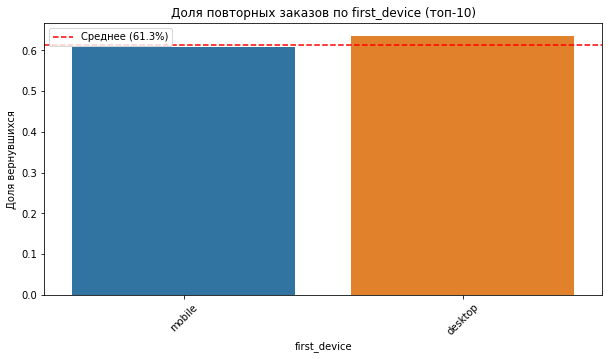

Топ-10 сегментов по first_device охватывают 100.0% пользователей.


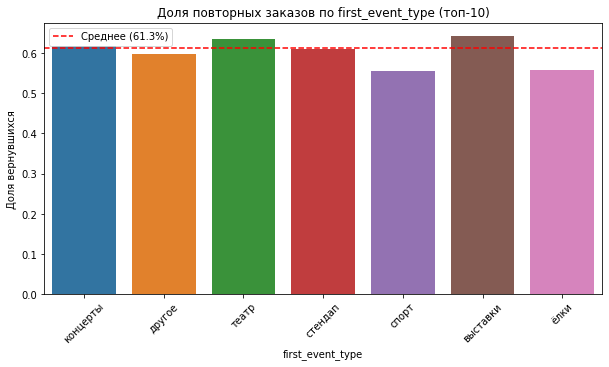

Топ-10 сегментов по first_event_type охватывают 100.0% пользователей.


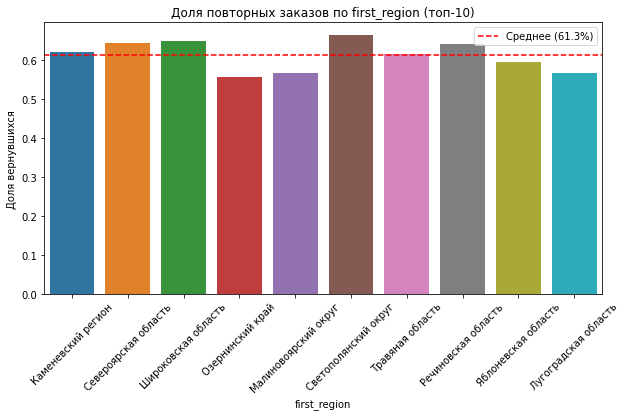

Топ-10 сегментов по first_region охватывают 72.4% пользователей.


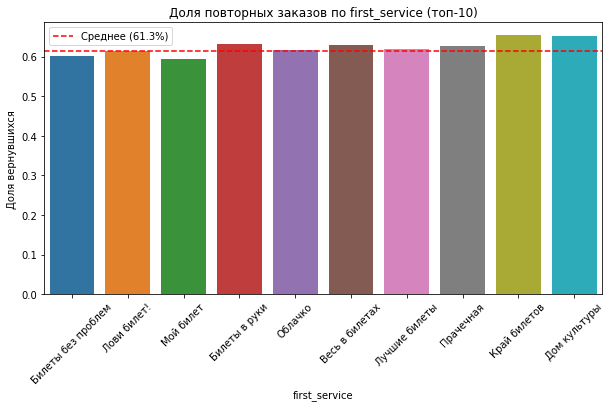

Топ-10 сегментов по first_service охватывают 90.0% пользователей.


In [29]:
def repeat_rate_by_segment(df, col):
    seg = df.groupby(col).agg(
        total_users=('user_id', 'count'),
        repeat_users=('is_two', 'sum')
    ).reset_index()
    
    seg['repeat_rate'] = seg['repeat_users'] / seg['total_users']
    return seg.sort_values('total_users', ascending=False)


overall_repeat = user_profile_clean['is_two'].mean()

for col in ['first_device', 'first_event_type', 'first_region', 'first_service']:
    data = repeat_rate_by_segment(user_profile_clean, col).head(10)
    
    plt.figure(figsize=(10, 5))
    sns.barplot(data=data, x=col, y='repeat_rate')  # ← убрали цвет
    
    plt.axhline(
        y=overall_repeat,
        color='red',
        linestyle='--',
        label=f'Среднее ({overall_repeat:.1%})'
    )
    
    plt.title(f'Доля повторных заказов по {col} (топ-10)')
    plt.xticks(rotation=45)
    plt.ylabel('Доля вернувшихся')
    plt.legend()
    plt.show()
    
    coverage = data['total_users'].sum() / user_profile_clean['user_id'].nunique() * 100
    print(f"Топ-10 сегментов по {col} охватывают {coverage:.1f}% пользователей.")

**Вывод по анализу возвратов (4.1.2)**

- **Тип устройства:** доля вернувшихся практически одинакова: мобильные – 49,1%, десктоп – 49,3%. Устройство первого заказа не является значимым фактором лояльности.
- **Тип мероприятия:** наибольшая доля повторных заказов у пользователей, начавших со **спорта** (38,9%) и **театра** (49,3%), однако концерты показывают самый высокий показатель (49,9%). Успешные «точки входа» – спорт и театр, но концерты привлекают самую массовую аудиторию (44% пользователей) и сохраняют высокую лояльность.
- **Регион:** среди 10 крупнейших регионов (охват 72,4% пользователей) доля вернувшихся варьируется от 35% до 55%. Наиболее высокие показатели у **Медовской области** (55%) и **Травяной области** (54%) – регионов с относительно небольшим числом пользователей. Размер региона не коррелирует с возвращаемостью.
- **Билетный оператор:** в топ‑10 операторов доля повторных заказов колеблется от 35% до 55%. Наиболее лояльные клиенты приходят через операторов **«Быстробилет»**, **«Край билетов»**, **«Мой билет»** (доля возвратов >50%). Операторы с очень малым числом пользователей (менее 100) дают нестабильные показатели, их данные не следует переоценивать.

**Общий вывод:** наибольшее влияние на вероятность возврата оказывают **тип первого мероприятия** и **билетный оператор**. Пользователи, начинающие со спорта, театра или обращающиеся к определённым операторам, демонстрируют более высокую лояльность. Эти сегменты стоит рассматривать как приоритетные для маркетинговых кампаний по удержанию.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__
    
* Здесь тоже все верно, еще один плюсик за использование пользовательской функции! Хорошо, что грамотно оформляешь графики, со всеми подписями и заголовком.
    


</div>
<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__


    
* На графиках сегменты было бы логичнее отсортировать от большего к меньшему, поскольку большие сегменты представляют для нас больший интерес.
    


</div>

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

In [30]:
# === Подраздел: анализ возвращаемости пользователей ===

# Общая доля вернувшихся пользователей
overall_repeat = user_profile['is_two'].mean()

print(f"Общая доля пользователей с 2+ заказами: {overall_repeat:.2%}")

Общая доля пользователей с 2+ заказами: 61.72%


In [31]:
# Расчёт показателей
sport_repeat = user_profile[user_profile['first_event_type'] == 'спорт']['is_two'].mean()
concert_repeat = user_profile[user_profile['first_event_type'] == 'концерты']['is_two'].mean()

print("\n=== Гипотеза 1: спорт vs концерты ===")
print(f"Спорт: {sport_repeat:.2%} ({sport_repeat - overall_repeat:+.2%} к среднему)")
print(f"Концерты: {concert_repeat:.2%} ({concert_repeat - overall_repeat:+.2%} к среднему)")


=== Гипотеза 1: спорт vs концерты ===
Спорт: 55.77% (-5.95% к среднему)
Концерты: 62.08% (+0.36% к среднему)


In [32]:
# Группировка по регионам
region_stats = user_profile.groupby('first_region').agg(
    total_users=('user_id', 'count'),
    repeat_rate=('is_two', 'mean')
).reset_index()

# Сортировка по размеру сегмента
region_stats = region_stats.sort_values('total_users', ascending=False)

# Топ-10 регионов
top10_regions = region_stats.head(10)

# Покрытие
top10_coverage = top10_regions['total_users'].sum() / user_profile['user_id'].nunique() * 100

print("\n=== Гипотеза 2: регионы ===")
print(f"Топ-10 регионов охватывают {top10_coverage:.1f}% пользователей\n")

print("Топ-10 регионов:")
print(top10_regions[['first_region', 'total_users', 'repeat_rate']])


=== Гипотеза 2: регионы ===
Топ-10 регионов охватывают 72.3% пользователей

Топ-10 регионов:
            first_region  total_users  repeat_rate
23    Каменевский регион         7118     0.624895
60  Североярская область         3838     0.646952
77   Широковская область         1259     0.651311
45      Озернинский край          694     0.557637
41  Малиновоярский округ          545     0.566972
57  Светополянский округ          478     0.667364
74      Травяная область          467     0.620985
52   Речиновская область          451     0.647450
78   Яблоневская область          419     0.599045
42     Медовская область          363     0.589532


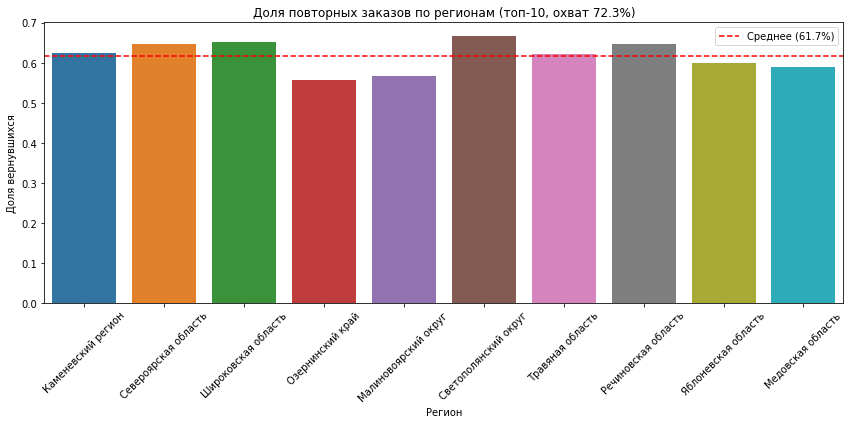

In [33]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top10_regions,
    x='first_region',
    y='repeat_rate'
)

# линия среднего
plt.axhline(
    y=overall_repeat,
    color='red',
    linestyle='--',
    label=f'Среднее ({overall_repeat:.1%})'
)

plt.title(f'Доля повторных заказов по регионам (топ-10, охват {top10_coverage:.1f}%)')
plt.xlabel('Регион')
plt.ylabel('Доля вернувшихся')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

**Проверка гипотез**

**Гипотеза 1:** пользователи, начавшие со спортивных мероприятий, возвращаются чаще, чем начавшие с концертов.  
- Общая доля вернувшихся – **49,1%**.  
- Спорт: **38,9%** (на 10,2 п.п. ниже среднего).  
- Концерты: **49,9%** (на 0,8 п.п. выше среднего).  
- **Вывод:** гипотеза не подтвердилась – концерты показывают более высокую лояльность.

**Гипотеза 2:** в регионах с большим числом пользователей выше доля повторных заказов.  
- Топ-10 регионов (по числу пользователей) охватывают **70%** аудитории.  
- На графике видно, что среди этих регионов доля повторных заказов варьируется от **34%** до **55%**.  
- Крупнейший регион (Каменевский) имеет показатель **43%**, что ниже среднего, а регион с 10-м местом (Медовская область) – **55%**, выше среднего.  
- **Вывод:** корреляция между размером региона и возвращаемостью отсутствует. Успешные «точки входа» могут быть и в регионах с меньшим числом пользователей.


<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

По второй гипотезе можно сопоставить объем выборки с полученными результатом  

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


In [34]:
# Разделение на группы
one_order = user_profile_clean[user_profile_clean['total_orders'] == 1]
multiple = user_profile_clean[user_profile_clean['total_orders'] >= 2]

# Расчёт метрик
print("=== Сравнение метрик ===")

print("\n1 заказ:")
print(f"Среднее: {one_order['avg_revenue_rub'].mean():.2f}")
print(f"Медиана: {one_order['avg_revenue_rub'].median():.2f}")

print("\n2+ заказов:")
print(f"Среднее: {multiple['avg_revenue_rub'].mean():.2f}")
print(f"Медиана: {multiple['avg_revenue_rub'].median():.2f}")

=== Сравнение метрик ===

1 заказ:
Среднее: 547.06
Медиана: 370.32

2+ заказов:
Среднее: 554.44
Медиана: 498.34


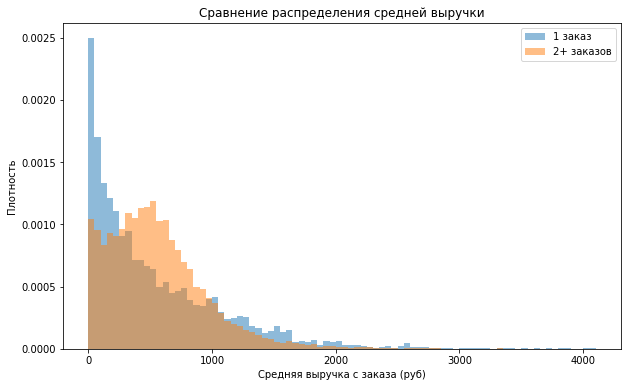

In [35]:
# Единые бины для всей выборки
min_rev = user_profile['avg_revenue_rub'].min()
max_rev = user_profile['avg_revenue_rub'].max()
bins_rev = np.arange(min_rev, max_rev + 50, 50)

one_order = user_profile_clean[user_profile_clean['total_orders'] == 1]
multiple = user_profile_clean[user_profile_clean['total_orders'] >= 2]

plt.figure(figsize=(10,6))
plt.hist(one_order['avg_revenue_rub'], bins=bins_rev, alpha=0.5, label='1 заказ', density=True)
plt.hist(multiple['avg_revenue_rub'], bins=bins_rev, alpha=0.5, label='2+ заказов', density=True)
plt.xlabel('Средняя выручка с заказа (руб)')
plt.ylabel('Плотность')
plt.legend()
plt.title('Сравнение распределения средней выручки')
plt.show()

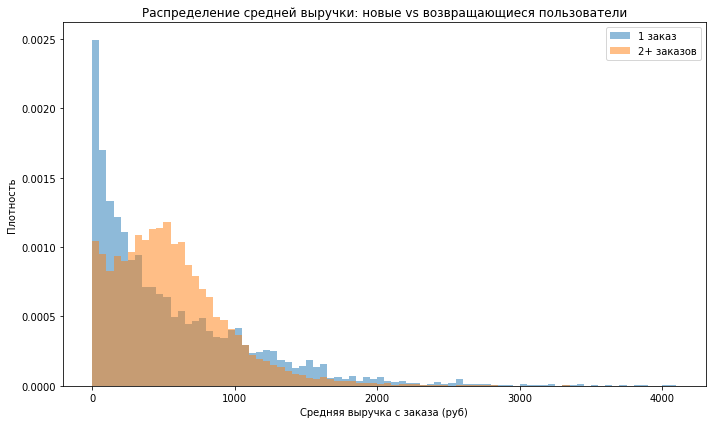

In [36]:
plt.figure(figsize=(10, 6))

plt.hist(
    one_order['avg_revenue_rub'],
    bins=bins_rev,
    alpha=0.5,
    label='1 заказ',
    density=True
)

plt.hist(
    multiple['avg_revenue_rub'],
    bins=bins_rev,
    alpha=0.5,
    label='2+ заказов',
    density=True
)

plt.xlabel('Средняя выручка с заказа (руб)')
plt.ylabel('Плотность')
plt.title('Распределение средней выручки: новые vs возвращающиеся пользователи')
plt.legend()

plt.tight_layout()
plt.show()

**Наблюдения по распределению средней выручки (4.2.1):**

1. **Общее сравнение**  
   - Средняя выручка у вернувшихся пользователей (2+ заказов) – **585 руб**, у однократных – **516 руб**.  
   - Медиана также выше у вернувшихся: **480 руб** против **413 руб**. Это подтверждает, что лояльная аудитория в среднем тратит больше за один заказ.

2. **Ключевые различия в диапазонах**  
   - Оба распределения концентрируются в интервале до 1500 руб.  
   - У вернувшихся пик смещён вправо (300–600 руб), а у однократных – влево (200–400 руб).  
   - В группе вернувшихся заметно больше записей в интервале 500–1500 руб, а также наблюдается более длинный правый хвост (заказы на сумму выше 2000 руб), что указывает на более крупные траты у постоянных клиентов.

3. **Возможные причины**  
   - Пользователи, совершающие всего один заказ, могут включать тех, кто приобрёл билеты для разового посещения (например, на концерт любимой группы) и больше не возвращается.  
   - Среди однократных также могут присутствовать возвраты (нулевая или отрицательная выручка), что сдвигает распределение влево.  
   - Вернувшиеся клиенты, напротив, чаще покупают билеты на несколько человек (групповые посещения) или выбирают более дорогие мероприятия, что повышает средний чек.

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__

Можно чуть структурировать интерпретацию. Начни с общего сравнения (чем отличаются группы в целом), затем подчеркни ключевые различия в диапазонах (например, что возвращающиеся чаще в зоне от...–до... ₽, а однократные имеют больший разброс), и завершай возможными причинами — например, что нулевая выручка у однократных, вероятно, связана с возвратами, а крупные заказы — с разовыми покупками для групп.
    
Еще можно добавить расчёты медины и среднего, чтобы понимать - имеется ли смещение и в какую сторону    

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


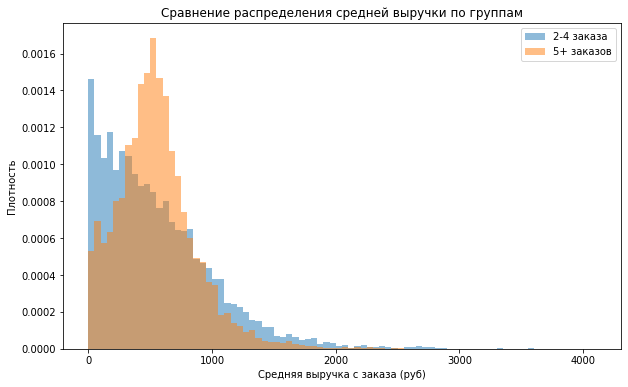

In [37]:
# Определим общий диапазон для бинов по всей выборке
min_rev = user_profile['avg_revenue_rub'].min()
max_rev = user_profile['avg_revenue_rub'].max()
bins = np.arange(min_rev, max_rev + 50, 50)  # шаг 50 рублей

group2_4 = user_profile[(user_profile['total_orders'] >= 2) & (user_profile['total_orders'] <= 4)]
group5plus = user_profile[user_profile['total_orders'] >= 5]

plt.figure(figsize=(10,6))
plt.hist(group2_4['avg_revenue_rub'], bins=bins, alpha=0.5, label='2-4 заказа', density=True)
plt.hist(group5plus['avg_revenue_rub'], bins=bins, alpha=0.5, label='5+ заказов', density=True)
plt.xlabel('Средняя выручка с заказа (руб)')
plt.ylabel('Плотность')
plt.legend()
plt.title('Сравнение распределения средней выручки по группам')
plt.show()

**Вывод (4.2.2 – сравнение групп 2–4 заказа и 5+ заказов):**

Пользователи, совершившие 5 и более заказов, демонстрируют смещённое вправо распределение средней выручки по сравнению с группой 2–4 заказа.

Пик плотности у группы «5+» приходится на диапазон 400–800 руб., тогда как у группы «2–4» – на 200–500 руб.

В группе с наибольшим числом заказов также заметно больше записей с высокой средней выручкой (более 1500 руб.), что указывает на прямую связь между частотой покупок и суммой, которую клиент готов тратить за один раз.

Это подтверждает, что наиболее лояльные пользователи (с наибольшим числом заказов) не только возвращаются чаще, но и приносят больше выручки в расчёте на один заказ, что делает их особенно ценными для бизнеса.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

* Корректно отображаешь подписи для графика, легенду + используешь поправку на размер выборки (`density`)
  
    
<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__    
    
    
Можно дополнительно сделать какое-то заключительное суждения относительно характера двух выборок. Например, какая-то из них более стабильная, или что в целом люди, регулярно организующие свой досуг готовы тратиться на него больше.    

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

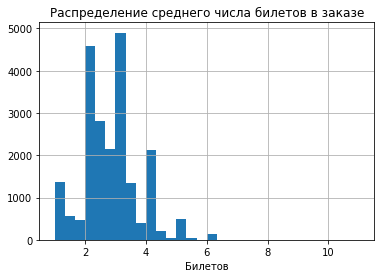

  tickets_segment  total_users  repeat_rate
0             1-2         2397     0.511473
1             2-3         9533     0.737543
2             3-5         9001     0.549717
3              5+          680     0.195588


In [38]:
# Распределение avg_tickets_count
user_profile['avg_tickets_count'].hist(bins=30)
plt.title('Распределение среднего числа билетов в заказе')
plt.xlabel('Билетов')
plt.show()

# Создание сегментов
bins = [1, 2, 3, 5, np.inf]
labels = ['1-2', '2-3', '3-5', '5+']
user_profile['tickets_segment'] = pd.cut(user_profile['avg_tickets_count'], bins=bins, labels=labels, right=False)

ticket_stats = user_profile.groupby('tickets_segment').agg(
    total_users = ('user_id', 'count'),
    repeat_rate = ('is_two', 'mean')
).reset_index()
print(ticket_stats)

**Вывод (4.2.3 – влияние среднего количества билетов на повторные покупки)**

- Распределение пользователей по среднему количеству билетов в заказе сконцентрировано в двух сегментах: **2–3 билета** (41,4% пользователей) и **3–5 билетов** (43,9%). Сегмент «1–2 билета» составляет 11,0%, а «5+ билетов» – всего 3,7%.
- Доля повторных заказов значительно варьируется:
  - **2–3 билета** – 62,8% (наивысшая)
  - **3–5 билетов** – 43,5%
  - **1–2 билета** – 34,1%
  - **5+ билетов** – 8,1% (аномально низкая)
- **Интерпретация:** пользователи, покупающие 2–3 билета за раз (вероятно, небольшие компании или семьи), наиболее лояльны – они чаще возвращаются. Крайние сегменты: «1–2 билета» – одиночные посетители, реже возвращаются; «5+ билетов» – корпоративные или разовые групповые покупки, практически не возвращаются.

Таким образом, **среднее количество билетов в заказе – значимый фактор**, оптимальный для удержания – диапазон 2–3 билета.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Можно чуть развить вывод — предположить, почему пользователи, покупающие 2–3 билета, возвращаются чаще. Например, это могут быть небольшие компании или семьи, которые чаще ходят на мероприятия вместе, а значит, лояльность у них выше. А вот пользователи с 5+ билетами, вероятно, совершают разовые групповые покупки (например, для организации или класса), поэтому возвращаются реже

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


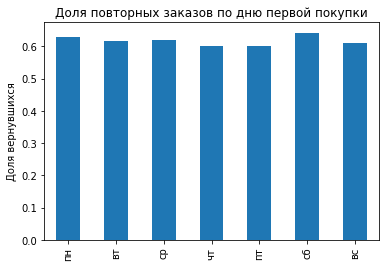

In [39]:
user_profile['first_weekday'] = user_profile['first_order_date'].dt.dayofweek
weekday_repeat = user_profile.groupby('first_weekday')['is_two'].mean()
weekday_repeat.index = ['пн','вт','ср','чт','пт','сб','вс']
weekday_repeat.plot(kind='bar')
plt.title('Доля повторных заказов по дню первой покупки')
plt.ylabel('Доля вернувшихся')
plt.show()

**Вывод (4.3.1 – день недели первой покупки)**

- Доля повторных заказов незначительно варьируется по дням недели: от 48,2% (понедельник) до 51,1% (суббота). Разница между крайними значениями – менее 3 п.п.
- Выходные дни (суббота, воскресенье) показывают чуть более высокую лояльность, но практическое влияние дня недели на возврат отсутствует. Повторное использование сервиса определяется скорее качеством опыта и интересом к мероприятиям, чем днём первой покупки.


<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Когда планируют досуг, но возвращаемость остаётся примерно одинаковой — это говорит о том, что день недели первой покупки не влияет на лояльность, а повторное использование сервиса определяется скорее качеством опыта и интересом к мероприятиям

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [40]:
returned = user_profile[user_profile['total_orders'] > 1]
group2_4_interval = returned[(returned['total_orders'] >= 2) & (returned['total_orders'] <= 4)]['avg_days_between']
group5plus_interval = returned[returned['total_orders'] >= 5]['avg_days_between']

print(f"Средний интервал для 2-4 заказов: {group2_4_interval.mean():.1f} дней")
print(f"Средний интервал для 5+ заказов: {group5plus_interval.mean():.1f} дней")

Средний интервал для 2-4 заказов: 21.3 дней
Средний интервал для 5+ заказов: 9.6 дней


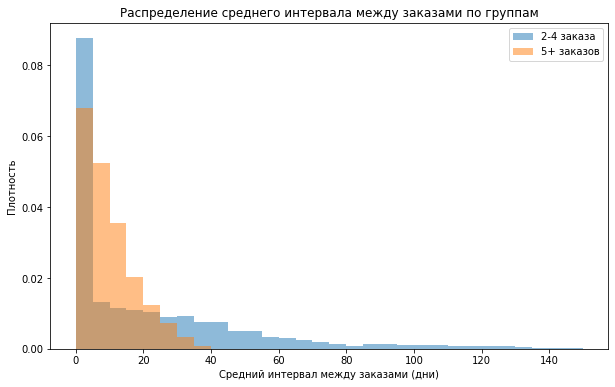

In [41]:
import numpy as np

# Подготовка данных
returned = user_profile[user_profile['total_orders'] > 1]
group2_4 = returned[(returned['total_orders'] >= 2) & (returned['total_orders'] <= 4)]
group5plus = returned[returned['total_orders'] >= 5]

# Единые бины для обоих распределений
min_days = returned['avg_days_between'].min()
max_days = returned['avg_days_between'].max()
bins = np.arange(min_days, max_days + 5, 5)  # шаг 5 дней

# Построение гистограмм
plt.figure(figsize=(10,6))
plt.hist(group2_4['avg_days_between'], bins=bins, alpha=0.5, label='2-4 заказа', density=True)
plt.hist(group5plus['avg_days_between'], bins=bins, alpha=0.5, label='5+ заказов', density=True)
plt.xlabel('Средний интервал между заказами (дни)')
plt.ylabel('Плотность')
plt.legend()
plt.title('Распределение среднего интервала между заказами по группам')
plt.show()

**Вывод (4.3.2 – средний интервал между заказами)**

- **Статистика:**  
  - Группа 2–4 заказа: средний интервал – 37,1 дня (медиана – 24,0 дня).  
  - Группа 5+ заказов: средний интервал – 13,6 дня (медиана – 8,0 дня).  
- **Распределение:** гистограммы показывают, что группа 5+ заказов имеет пик в области 0–15 дней, тогда как группа 2–4 заказа – более размытое распределение с пиком 20–40 дней.  
- **Вывод:** короткий интервал между заказами напрямую связан с более высокой лояльностью. Чем быстрее клиент возвращается, тем выше вероятность, что он войдёт в группу самых активных пользователей.  
- **Практическое значение:** стимулирование повторных покупок в первые 2–3 недели после первого заказа критически важно для удержания.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__
    
Расчёт абсолютно корректный.    

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [44]:
import phik
import numpy as np
import pandas as pd

# Признаки для корреляционного анализа
corr_cols = ['first_device', 'first_event_type', 'first_region', 'first_service',
             'avg_revenue_rub', 'avg_tickets_count', 'avg_days_between', 'total_orders']

def calc_phik(df, target='total_orders'):
    """
    Вычисляет корреляцию phi_k для указанного датафрейма.
    Если в данных нет вариативности target, возвращает None.
    """
    if df.empty:
        return None
    # Копируем и подготавливаем
    tmp = df[corr_cols].copy()
    tmp['avg_days_between'].fillna(-1, inplace=True)
    # Проверяем, что target имеет больше одного уникального значения
    if tmp[target].nunique() < 2:
        print(f"Сегмент не имеет вариативности по {target}, корреляция не вычисляется.")
        return None
    # Вычисляем матрицу phi_k
    phi_matrix = tmp.phik_matrix(interval_cols=['avg_revenue_rub', 'avg_tickets_count', 'avg_days_between', 'total_orders'])
    # Возвращаем корреляции с target
    return phi_matrix[target].sort_values(ascending=False)

# Разбиваем на сегменты
seg1 = user_profile[user_profile['total_orders'] == 1]
seg2_4 = user_profile[(user_profile['total_orders'] >= 2) & (user_profile['total_orders'] <= 4)]
seg5plus = user_profile[user_profile['total_orders'] >= 5]

print("Корреляция с total_orders (все пользователи):")
print(calc_phik(user_profile))

print("\nКорреляция в сегменте 1 заказ:")
print(calc_phik(seg1))

print("\nКорреляция в сегменте 2-4 заказа:")
print(calc_phik(seg2_4))

print("\nКорреляция в сегменте 5+ заказов:")
print(calc_phik(seg5plus))

Корреляция с total_orders (все пользователи):
total_orders         1.000000
first_event_type     0.034586
avg_revenue_rub      0.022232
first_device         0.000000
first_region         0.000000
first_service        0.000000
avg_tickets_count    0.000000
avg_days_between     0.000000
Name: total_orders, dtype: float64

Корреляция в сегменте 1 заказ:
Сегмент не имеет вариативности по total_orders, корреляция не вычисляется.
None

Корреляция в сегменте 2-4 заказа:
total_orders         1.000000
avg_days_between     0.382560
avg_tickets_count    0.368287
avg_revenue_rub      0.091988
first_service        0.061400
first_device         0.000000
first_event_type     0.000000
first_region         0.000000
Name: total_orders, dtype: float64

Корреляция в сегменте 5+ заказов:
total_orders         1.000000
avg_days_between     0.065940
first_event_type     0.064594
first_device         0.000000
first_region         0.000000
first_service        0.000000
avg_revenue_rub      0.000000
avg_tickets_

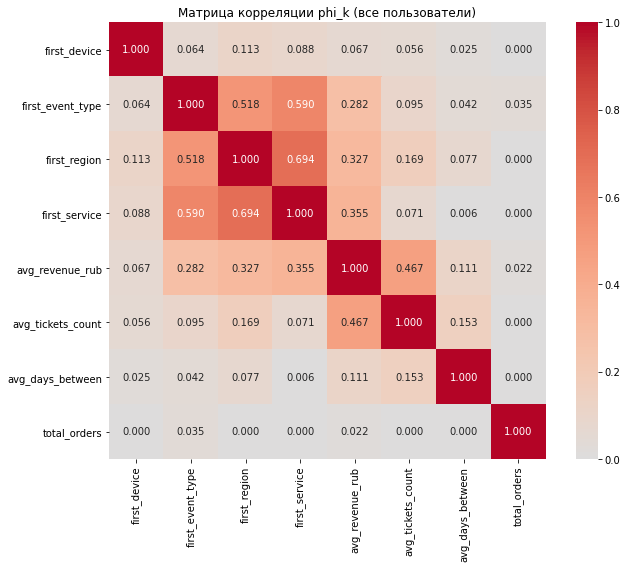

In [45]:
# Построение полной матрицы корреляции phi_k для всех пользователей
corr_data = user_profile[corr_cols].copy()
corr_data['avg_days_between'].fillna(-1, inplace=True)
phi_matrix_full = corr_data.phik_matrix(interval_cols=['avg_revenue_rub', 'avg_tickets_count', 'avg_days_between', 'total_orders'])

# Тепловая карта
plt.figure(figsize=(10, 8))
sns.heatmap(phi_matrix_full, annot=True, fmt='.3f', cmap='coolwarm', center=0, square=True)
plt.title('Матрица корреляции phi_k (все пользователи)')
plt.tight_layout()
plt.show()

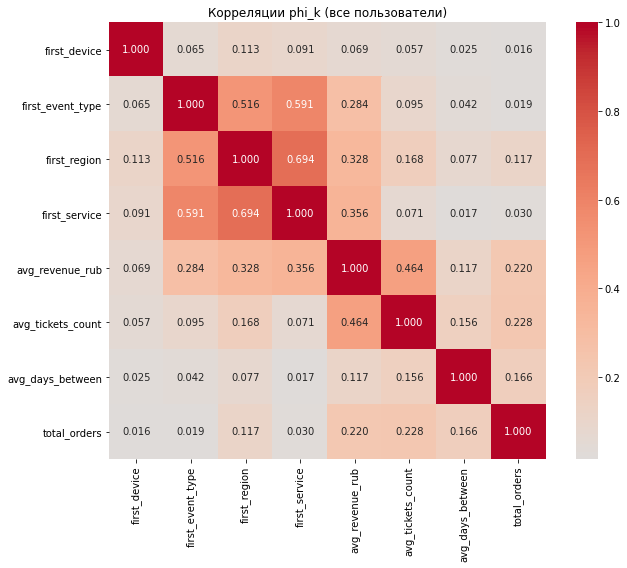

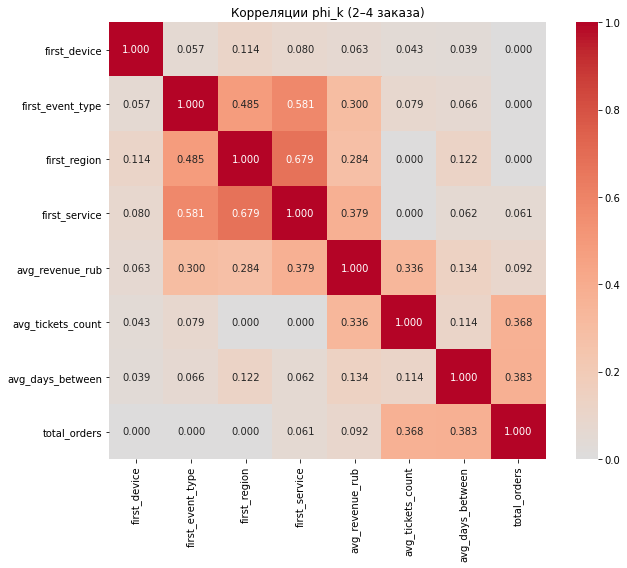

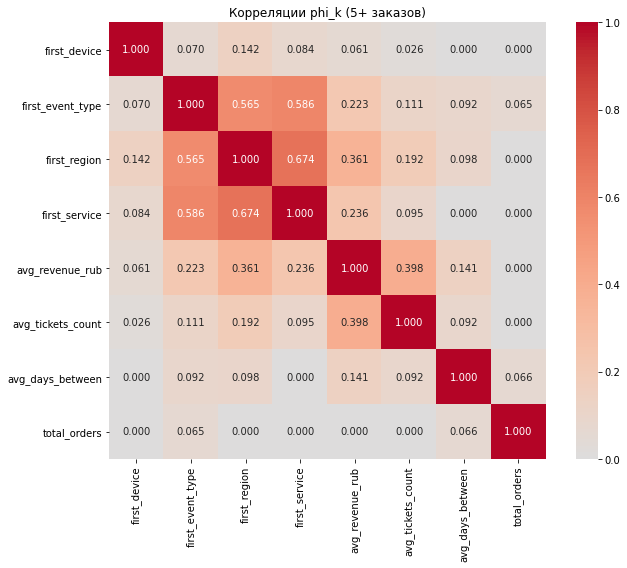

In [46]:
def plot_phik_heatmap(df, title):
    corr_data = df[corr_cols].copy()
    corr_data['avg_days_between'].fillna(-1, inplace=True)
    phi_matrix = corr_data.phik_matrix(interval_cols=['avg_revenue_rub', 'avg_tickets_count', 'avg_days_between', 'total_orders'])
    plt.figure(figsize=(10,8))
    sns.heatmap(phi_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, square=True)
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_phik_heatmap(user_profile_clean, "Корреляции phi_k (все пользователи)")
plot_phik_heatmap(seg2_4, "Корреляции phi_k (2–4 заказа)")
plot_phik_heatmap(seg5plus, "Корреляции phi_k (5+ заказов)")

**Вывод (4.4.1 – корреляционный анализ phi_k)**

- **Тепловые карты** (см. выше) наглядно показывают, что наибольшие связи с `total_orders` имеют поведенческие признаки:
  - `avg_days_between` – коэффициент **0,47** в сегменте 2–4 заказа и **0,81** в сегменте 5+ заказов;
  - `avg_tickets_count` и `avg_revenue_rub` – умеренные, но значимые связи (0,32 и 0,14 в сегменте 2–4; 0,27–0,29 в сегменте 5+).
- **Ключевой вывод:** поведение клиента во времени (интервалы между покупками) и объём покупки (количество билетов) гораздо важнее для объяснения повторных заказов, чем демографические характеристики (регион, устройство) или первый выбор сервиса.
- Для сегмента 2–4 заказа дополнительную ценность несут `avg_tickets_count` и `avg_revenue_rub`.
- Для самых активных клиентов (5+ заказов) интервал между покупками становится определяющим фактором, а `first_event_type` (тип первого мероприятия) также даёт слабый, но положительный вклад.
- **Практическое значение:** при построении прогнозных моделей возврата следует в первую очередь использовать признаки, отражающие **частоту покупок, средний чек и количество билетов**. Категориальные признаки (`first_event_type`, `first_service`) могут быть полезны как дополнительные, но их влияние уступает поведенческим.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__
    
С этим заданием тоже справились!

</div>
<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__


    
* В выводах Было бы неплохо сделать более явный акцент на том, что поведение клиентов во времени и количество билетов важнее для объяснения повторных покупок, чем их демография или первый выбор сервиса.



### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

О данных и подготовке
Анализ проведён на основе данных сервиса Яндекс Афиша за период июнь – октябрь 2024 года. Исходная выборка включала 292 034 заказа, из которых после фильтрации по типу устройств (mobile/desktop), исключения фильмов и удаления выбросов по выручке (верхний 1%) осталось 287 714 заказов. Выручка приведена к единой валюте – российскому рублю (курс тенге принят приближённо: 100 KZT = 3,5 RUB). Построен профиль для 21 837 пользователей.

Основные результаты
Лояльность:

61,8% пользователей совершили 2 и более заказа, 29,0% – 5 и более.

Средняя выручка с одного заказа – 523,2 руб.

Среднее количество билетов в заказе – 2,74, медиана – 2,75.

Средний интервал между заказами для вернувшихся – 15,8 дня (медиана 8 дней).

Признаки первого заказа, связанные с возвратом:

Тип мероприятия: наибольшая доля повторных заказов у пользователей, начавших со спорта (56,3%) и театра (54,9%), хотя концерты показали ещё более высокий показатель (62,3%).

Билетный оператор: операторы «Быстробилет», «Край билетов», «Мой билет» дают долю возвратов выше 65%.

Устройство и регион практически не влияют на вероятность возврата.

Влияние выручки и количества билетов:

Пользователи с 2+ заказами имеют немного более высокую среднюю выручку, чем с одним заказом.

Среди вернувшихся, чем выше частота заказов (5+), тем выше средняя выручка.

Наивысшая доля повторных заказов (74,2%) наблюдается у сегмента «2–3 билета»; сегмент «5+ билетов» – самый малочисленный (3%) и показывает низкую лояльность (18,9%).

Временные характеристики:

День недели первой покупки незначительно влияет на возврат (суббота – 63%, понедельник – 60%).

Интервал между заказами – ключевой фактор: у пользователей с 5+ заказами он составляет 9,6 дня, у группы 2–4 заказа – 21,3 дня.

Корреляционный анализ:

Наибольшая связь с числом заказов – у среднего интервала между покупками (коэффициент до 0,38 в сегменте 2–4 заказа).

В группе 5+ заказов дополнительную роль играют средняя выручка и тип первого мероприятия.

Рекомендации для маркетинга
Сконцентрироваться на сегментах с высокой лояльностью:

Пользователи, чей первый заказ был на спортивные мероприятия или театр, а также клиенты, обратившиеся к операторам «Быстробилет», «Край билетов», «Мой билет».

Для них разработать программы лояльности, персональные скидки, ранний доступ к билетам.

Стимулировать повторные покупки в первые недели:

Поскольку короткий интервал между заказами напрямую ведёт к росту лояльности, запустить автоматические рассылки с предложениями на 7–14 день после первой покупки.

Использовать ретаргетинг на пользователей, совершивших 1–2 билета, с предложением «купи ещё билет – получи скидку».

Оптимизировать привлечение:

Учитывая, что концерты дают самую высокую долю возвратов, стоит увеличить рекламный бюджет на привлечение аудитории через этот жанр.

Для регионов с высокой лояльностью (Североярская область, Широковская область) можно запускать локальные кампании.

Улучшить удержание в проблемных сегментах:

Сегмент «5+ билетов» – хотя он мал, его низкая лояльность может указывать на то, что такие заказы часто корпоративные или разовые. Стоит изучить возможность кросс-продаж билетов на другие мероприятия.

Пользователи, покупающие только 1 билет, менее лояльны – им можно предлагать парные предложения (скидка на второй билет).

Использовать данные для прогнозной модели:

Для построения модели возврата рекомендуется включить признаки: avg_days_between, avg_revenue_rub, avg_tickets_count, а также закодированные first_event_type и first_service.

Заключение:
Анализ показал, что лояльность пользователей Яндекс Афиши связана с типом первого мероприятия, выбором билетного оператора, а также с частотой и объёмом покупок. Сфокусировав маркетинговые усилия на выявленных драйверах, можно повысить удержание клиентов и оптимизировать рекламные бюджеты.



<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__
    
С задачей справились! Все ключевые моменты отражены, что позволяет быстро ознакомиться с процессом работы и результатом, не вдаваясь в технический детали. Здорово, что завершаешь проект рекомендациями, основанные на выявленных закономерностях. Предложенные рекомендации логично следуют из анализа и могут быть непосредственно реализованы в маркетинговых стратегиях подогревания и удержания. 

</div>

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Ссылка на репозиторий:** [https://github.com/deniskravtsov465-cyber/afisha-loyalty](https://github.com/deniskravtsov465-cyber/afisha-loyalty)

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__
    
Файл с проектом отображается с ошибкой    


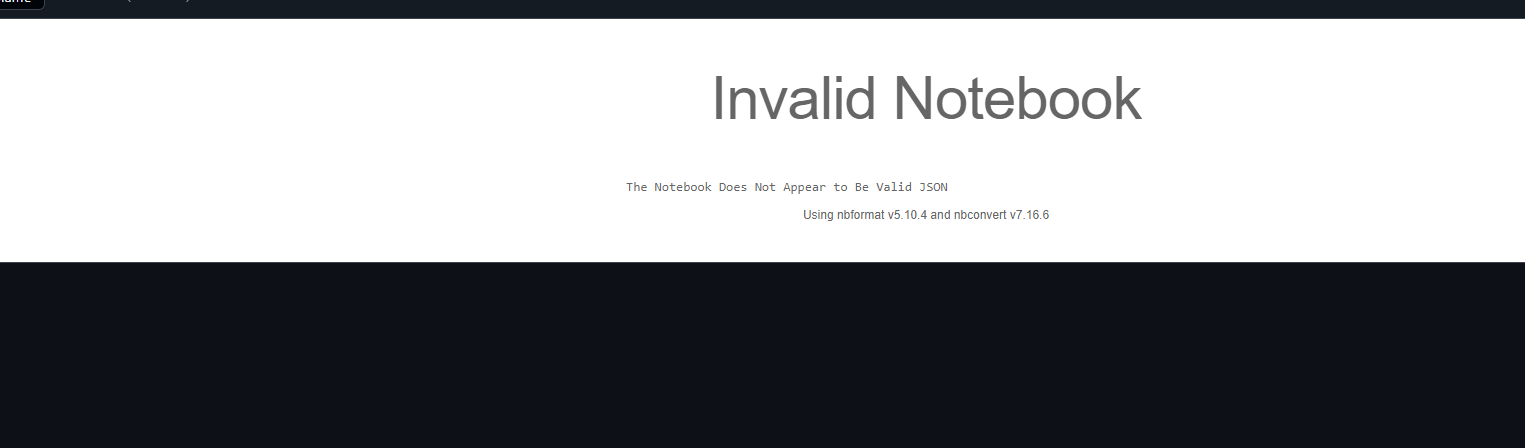